# High-Velocity Reentry Vehicle Tracking: EKF vs UKF

## Learning Objectives
- **Understand** the Unscented Transform vs linearizations in highly nonlinear scenarios.
- **Implement** a continuous-discrete Extended Kalman Filter (EKF) and Unscented Kalman Filter (UKF).
- **Evaluate** tracking performance during high-velocity reentry.
- **Tune** filter parameters to observe stability changes.

## Theory Recap

The **Extended Kalman Filter (EKF)** approximates nonlinear transformations by linearizing the process and observation models using a first-order Taylor series (Jacobians). 
For highly nonlinear systems, truncating at the first order introduces significant bias in the predicted mean and covariance.

The **Unscented Kalman Filter (UKF)** uses the **Unscented Transform (UT)**: propagating a deterministically chosen set of sample points (sigma points) through the true nonlinear functions.
The UT is proven to be accurate up to the **second order** of the Taylor series expansion for any nonlinear function, outperforming the EKF without calculating Jacobians.


In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*lsoda.*')
warnings.filterwarnings('ignore', message='.*LSODA.*')
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Prepend the estimation package src directory to path
# src is one level up from tutorials/
sys.path.insert(0, os.path.abspath('../src'))
import estimation as est

#np.random.seed(42)
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 4)})


## The Falling Body Reentry Dynamics

A vehicle re-enters the atmosphere at high velocity. We track its altitude $x_1(t)$, velocity $x_2(t)$, and a constant ballistic coefficient $x_3(t)$.

The continuous-time dynamics are:
$$ \dot{x}_1(t) = -x_2(t) + w_1(t) $$
$$ \dot{x}_2(t) = -e^{-\gamma x_1(t)} x_2(t)^2 x_3(t) + w_2(t) $$
$$ \dot{x}_3(t) = w_3(t) $$
where $\gamma = 5 \times 10^{-5}$ relates air density with altitude.

The radar distance $M = 100,000$ ft horizontally, and its altitude $H = 100,000$ ft.
The range measurement $z(t)$ recorded every 1 second is:
$$ z(t) = \sqrt{M^2 + (x_1(t) - H)^2} + \nu(t) $$


In [2]:
# --- Simulation Parameters (from Julier 1996) ---
gamma = 5e-5
M = 100000.0  # Radar horizontal offset [ft]
H = 100000.0  # Radar altitude [ft]
dt_meas = 1.0 # Measurement interval [s]
T_total = 60.0 # Total tracking time [s]

# Noise parameters
sigma_r = 100.0  # Range noise std [ft]
R = np.array([[sigma_r**2]])

# Initial true states [altitude, velocity, ballistic coeff]
x_true_0 = np.array([300000.0, 20000.0, 1e-5])

def true_dynamics(X, t):
    x1, x2, x3 = X
    dx1 = -x2
    dx2 = -np.exp(np.clip(-gamma * x1, -700, 100)) * (x2**2) * x3
    dx3 = 0.0
    # Process noise is added here to strictly match the request
    w = np.random.multivariate_normal(np.zeros(3), 1e-15 * np.eye(3))
    return np.array([dx1, dx2, dx3]) + w

def true_measurement(x1):
    return np.sqrt(M**2 + (x1 - H)**2)

# --- Simulate true trajectory using ODEInt (RK4-like) ---
N_steps = int(T_total / dt_meas)
t_sim = np.linspace(0, T_total, N_steps + 1)

# Because odeint evaluates internally multiple times, we'll use a fixed-step Euler method 
# to properly integrate the stochastic differential equation, as adding noise inside true_dynamics 
# breaks the deterministic assumptions of odeint.
x_true_hist = np.zeros((N_steps + 1, 3))
x_true_hist[0] = x_true_0

num_substeps = 10
dt_sub = dt_meas / num_substeps

x_current = x_true_0.copy()
for k in range(N_steps):
    for _ in range(num_substeps):
        # true_dynamics computes dx/dt + w
        dx = true_dynamics(x_current, None)
        x_current = x_current + dx * dt_sub
    x_true_hist[k+1] = x_current

# Generate noisy measurements
z_meas = np.array([true_measurement(x[0]) + sigma_r * np.random.randn() for x in x_true_hist])


## Step-by-Step Implementation: EKF and UKF Models

We will initialize `ExtendedKalmanFilter` and `UnscentedKalmanFilter` using the same system model.
**Note**: The EKF requires a Jacobian of the state dynamics (`Phi`) and the observation function (`H`). The UKF just needs the function evaluations.


In [3]:
class ReentryModel:
    def dynamics(self, X, t):
        x1, x2, x3 = X
        dx1 = -x2
        dx2 = -np.exp(np.clip(-gamma * x1, -700, 100)) * (x2**2) * x3
        dx3 = 0.0
        return np.array([dx1, dx2, dx3])
        
    def Phi(self, X, t):
        x1, x2, x3 = X
        # EKF State Jacobian
        F = np.zeros((3, 3))
        F[0, 1] = -1.0
        F[1, 0] = gamma * np.exp(np.clip(-gamma * x1, -700, 100)) * (x2**2) * x3
        F[1, 1] = -2.0 * np.exp(np.clip(-gamma * x1, -700, 100)) * x2 * x3
        F[1, 2] = -np.exp(np.clip(-gamma * x1, -700, 100)) * (x2**2)
        return F
        
    def f(self, X):
        # Fixed-step RK4 integration (avoids LSODA warnings from odeint).
        # Uses 10 sub-steps of dt_meas for accuracy.
        n_sub = 10
        h = dt_meas / n_sub
        x = np.array(X, dtype=float)
        for _ in range(n_sub):
            k1 = self.dynamics(x,           0.0)
            k2 = self.dynamics(x + 0.5*h*k1, 0.0)
            k3 = self.dynamics(x + 0.5*h*k2, 0.0)
            k4 = self.dynamics(x +     h*k3, 0.0)
            x = x + (h / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)
        return x
        
    def h(self, X):
        x1 = X[0]
        return np.array([np.sqrt(M**2 + (x1 - H)**2)])
        
    def H(self, X):
        # EKF Measurement Jacobian
        x1 = X[0]
        denom = np.sqrt(M**2 + (x1 - H)**2)
        return np.array([[(x1 - H) / denom, 0.0, 0.0]])

# Add small process noise to prevent covariance collapse and model actual uncertainty
Q = 1e-15 * np.eye(3)
model = ReentryModel()

# Initial Filter Guesses (Initial ballistic coefficient guessed badly intentionally!)
x_est_0 = np.array([300000.0, 20000.0, 3e-5])
P_0 = np.diag([1e6, 4e6, 1e-4])

# Initialise filters
state_ekf_0 = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
state_ukf_0 = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)

ekf = est.ExtendedKalmanFilter(model, Q, R, state_ekf_0, dt_meas)
ukf = est.UnscentedKalmanFilter(model, Q, R, state_ukf_0, dt_meas, kappa=0.0) # Original UT formulation


## Running the Filter Loop
Iterate over the measurement epochs and track the diverging estimation results.


In [4]:
# Histories
ekf_err = np.zeros((3, N_steps))
ukf_err = np.zeros((3, N_steps))
ekf_P = np.zeros((3, N_steps))
ukf_P = np.zeros((3, N_steps))

for m in range(1, N_steps + 1):
    z_k = np.array([z_meas[m]])
    
    # EKF Step
    ekf.predict()
    ekf.correct(z_k)
    ekf_err[:, m-1] = ekf.state_post.x - x_true_hist[m]
    ekf_P[:, m-1]   = np.diag(ekf.state_post.P)
    
    # UKF Step
    ukf.predict()
    ukf.correct(z_k)
    ukf_err[:, m-1] = ukf.state_post.x - x_true_hist[m]
    ukf_P[:, m-1]   = np.diag(ukf.state_post.P)


/Users/nishchal_mac/Desktop/Estimation_Theory/src/estimation/sequential.py:211: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  y_out = odeint(self._augmented_ode, y0, t_span)[-1, :]


## Visualization: Comparative Errors

We will plot the altitude, velocity, and ballistic coefficient estimation errors over time, comparing the EKF with the UKF. Notice how the EKF suffers catastrophically when the vehicle falls close enough for the drag non-linearity to dominate.


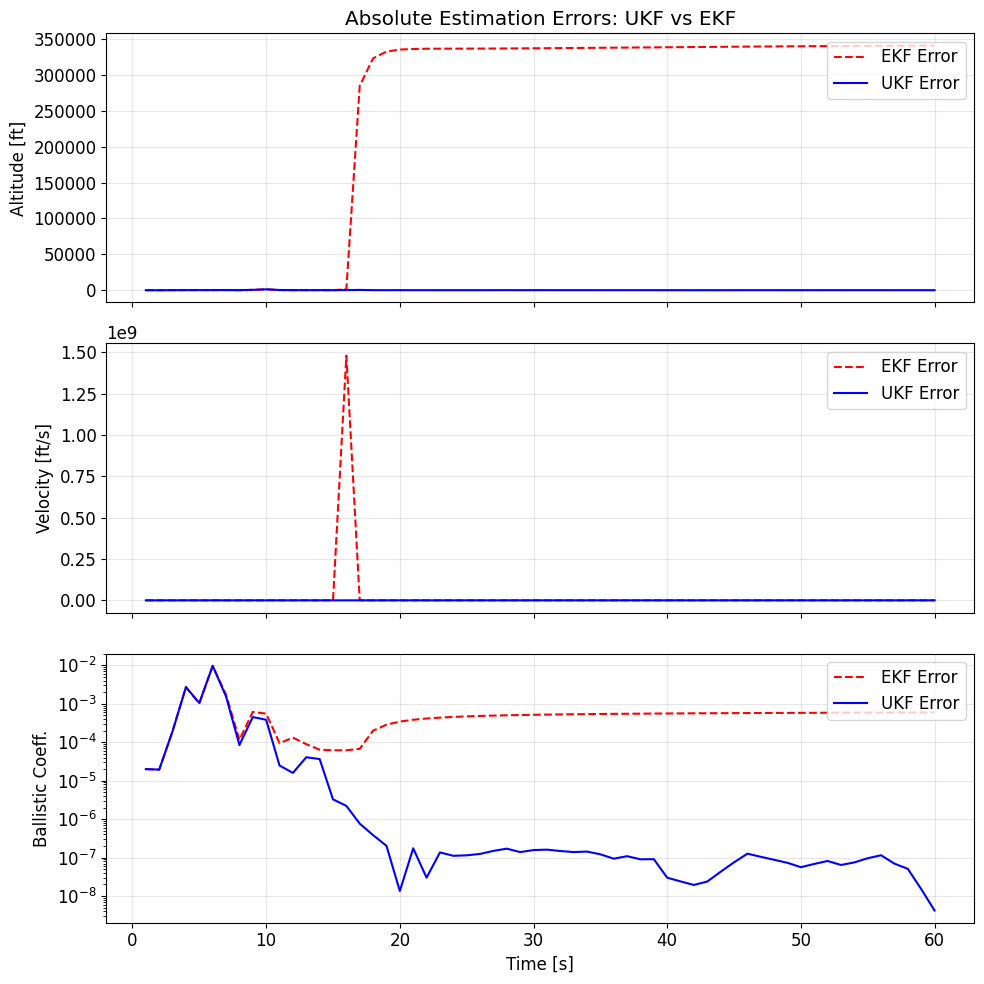

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
states = ["Altitude [ft]", "Velocity [ft/s]", "Ballistic Coeff."]

for i, ax in enumerate(axes):
    ax.plot(t_sim[1:], np.abs(ekf_err[i]), 'r--', label='EKF Error')
    ax.plot(t_sim[1:], np.abs(ukf_err[i]), 'b-', label='UKF Error')
    ax.set_ylabel(states[i])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    if i == 2:
        ax.set_yscale('log')

axes[-1].set_xlabel("Time [s]")
axes[0].set_title("Absolute Estimation Errors: UKF vs EKF")
plt.tight_layout()
plt.show()


## Monte Carlo Simulation (100 Runs)

To rigorously compare the filters and replicate the results from the Julier 1996 paper, we execute a Monte Carlo simulation over 100 runs. In each run, new Gaussian noise is generated for the measurements. We then compute the average absolute estimation error for both the EKF and UKF across all runs. Runs where a filter catastrophically diverges are excluded from the average.


In [6]:
# ── Monte Carlo runner (must run before the boxplot cell below) ─────────────
N_mc = 100
ekf_err_mc = np.full((N_mc, 3, N_steps), np.nan)
ukf_err_mc = np.full((N_mc, 3, N_steps), np.nan)

for run in range(N_mc):
    # Fresh true trajectory with a new noise realisation
    x_c = x_true_0.copy()
    x_hist_mc = np.zeros((N_steps + 1, 3))
    x_hist_mc[0] = x_c
    for k in range(N_steps):
        for _ in range(num_substeps):
            dx = true_dynamics(x_c, None)
            x_c = x_c + dx * dt_sub
        x_hist_mc[k + 1] = x_c

    z_mc = np.array(
        [true_measurement(x[0]) + sigma_r * np.random.randn() for x in x_hist_mc]
    )

    # Re-initialise filters (same Q and kappa as cell 5)
    state_ekf_r = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    state_ukf_r = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    ekf_r = est.ExtendedKalmanFilter(model, Q, R, state_ekf_r, dt_meas)
    ukf_r = est.UnscentedKalmanFilter(model, Q, R, state_ukf_r, dt_meas, kappa=0.0)

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_mc[m]])
            ekf_r.predict()
            ekf_r.correct(z_k)
            ekf_err_mc[run, :, m - 1] = ekf_r.state_post.x - x_hist_mc[m]
    except Exception:
        pass  # leave as NaN for diverged run

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_mc[m]])
            ukf_r.predict()
            ukf_r.correct(z_k)
            ukf_err_mc[run, :, m - 1] = ukf_r.state_post.x - x_hist_mc[m]
    except Exception:
        pass

n_div_ekf = int(np.sum(np.any(np.isnan(ekf_err_mc[:, 0, :]), axis=1)))
n_div_ukf = int(np.sum(np.any(np.isnan(ukf_err_mc[:, 0, :]), axis=1)))
print(f"Monte Carlo complete ({N_mc} runs).  "
      f"Diverged EKF: {n_div_ekf}   Diverged UKF: {n_div_ukf}")


/var/folders/cw/4m37hl1j33ggv48mmy6vc8fm0000gn/T/ipykernel_37232/1207740812.py:5: RuntimeWarning: overflow encountered in scalar power
  dx2 = -np.exp(np.clip(-gamma * x1, -700, 100)) * (x2**2) * x3
/Users/nishchal_mac/miniconda3/envs/ani_env2/lib/python3.10/site-packages/numpy/_core/numeric.py:971: RuntimeWarning: overflow encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)
/Users/nishchal_mac/miniconda3/envs/ani_env2/lib/python3.10/site-packages/numpy/_core/numeric.py:971: RuntimeWarning: invalid value encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)
/Users/nishchal_mac/Desktop/Estimation_Theory/src/estimation/sequential.py:360: RuntimeWarning: invalid value encountered in multiply
  P_priori += self.Wc[i] * np.outer(diff, diff)
/Users/nishchal_mac/Desktop/Estimation_Theory/src/estimation/sequential.py:359: RuntimeWarning: invalid value encountered in subtract
  diff = sigmas_f_propagated[i] - x_prio

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2300000000000D+02   r2 =  0.1297987123602D-32
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2300000000000D+02   r2 =  0.1297987123602D-32
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2300000000000D+02   r2 =  0.1192386573086D-30
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2300000000000D+02   r2 =  0.1192386573086D-30
 lsoda--  warning..internal t (=r1) 

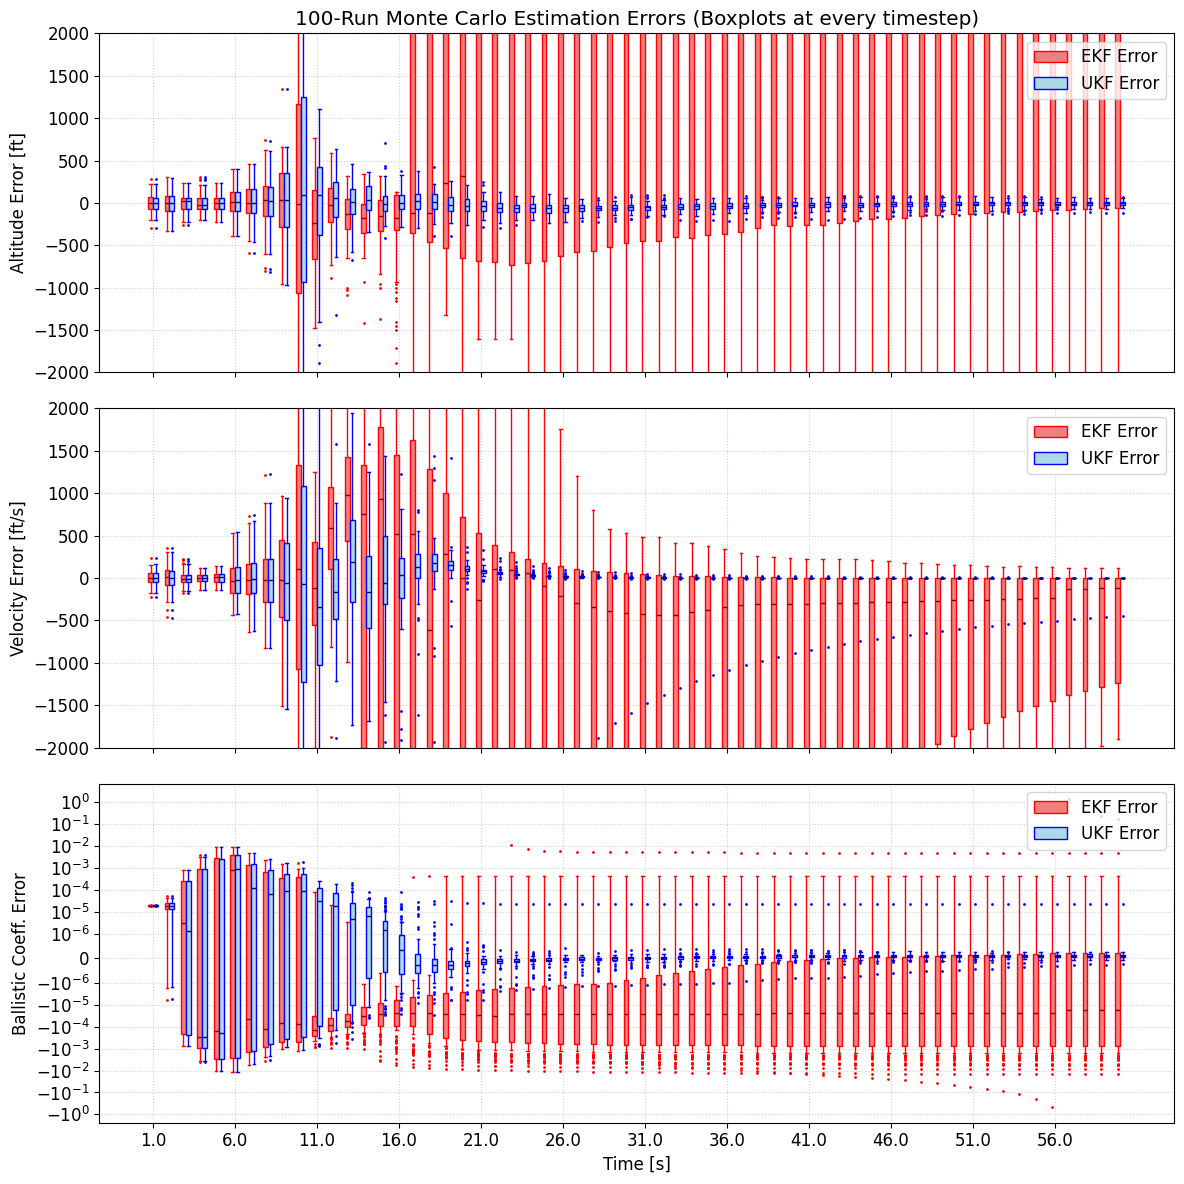

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
states = ["Altitude Error [ft]", "Velocity Error [ft/s]", "Ballistic Coeff. Error"]

# Filter out NaNs for boxplots
def get_valid_data(error_mc, state_idx, t_idx):
    data = error_mc[:, state_idx, t_idx]
    return data[~np.isnan(data)]

positions = t_sim[1:]
width = (t_sim[1] - t_sim[0]) * 0.3

for i, ax in enumerate(axes):
    ekf_data = [get_valid_data(ekf_err_mc, i, t) for t in range(N_steps)]
    ukf_data = [get_valid_data(ukf_err_mc, i, t) for t in range(N_steps)]
    
    # EKF Boxplots (red hue)
    bplot1 = ax.boxplot(ekf_data, positions=positions - width/2, widths=width, 
                        patch_artist=True, manage_ticks=False,
                        boxprops=dict(facecolor='lightcoral', color='red'),
                        capprops=dict(color='red'),
                        whiskerprops=dict(color='red'),
                        flierprops=dict(color='red', markeredgecolor='red', marker='.', markersize=2),
                        medianprops=dict(color='darkred'))
                        
    # UKF Boxplots (blue hue)
    bplot2 = ax.boxplot(ukf_data, positions=positions + width/2, widths=width, 
                        patch_artist=True, manage_ticks=False,
                        boxprops=dict(facecolor='lightblue', color='blue'),
                        capprops=dict(color='blue'),
                        whiskerprops=dict(color='blue'),
                        flierprops=dict(color='blue', markeredgecolor='blue', marker='.', markersize=2),
                        medianprops=dict(color='darkblue'))

    ax.set_ylabel(states[i])
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Add custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='lightcoral', edgecolor='red', label='EKF Error'),
                       Patch(facecolor='lightblue', edgecolor='blue', label='UKF Error')]
    ax.legend(handles=legend_elements, loc='upper right')
    
    if i == 2:
        # Note: boxplots with negative values don't work well on log scale. We can use symlog.
        ax.set_yscale('symlog', linthresh=1e-6)
axes[0].set_ylim([-2000,2000])
axes[1].set_ylim([-2000,2000])
axes[-1].set_xlabel("Time [s]")
axes[-1].set_xticks(positions[::5]) # Show every 5th tick to avoid clutter
axes[-1].set_xticklabels([f"{t:.1f}" for t in positions[::5]])
axes[0].set_title(f"{N_mc}-Run Monte Carlo Estimation Errors (Boxplots at every timestep)")
plt.tight_layout()
plt.show()

## Challenge Problem

**Task:** Currently, we have added a tiny amount of process noise ($Q = 10^{-10} I$). 
In reality, the initial velocity is massive, and drag might perturb it. 

1. Modify `Q` (the Process Noise Covariance) matrix inside the notebook and rerun the filter loop. What happens to the convergence speed when you increase the process noise variance significantly (e.g., $Q = 10^{-2} I$)?
2. **Sigma Point Parameter Tuning:** Change the `kappa` value in `UnscentedKalmanFilter(...)` from `0.0` to `3.0 - len(X)`. Watch how the initial bounds adapt.

```python
# TODO: Implement a continuous process noise spectral density matrix!
# HINT: Q = G @ Q_c @ G.T
```


---
## Challenge Problem — Solution

### Task 1 — Effect of Process Noise Magnitude on Convergence

We re-run **both filters** with three different levels of isotropic process noise $Q = q \cdot I_3$:

| $q$ | Physical interpretation |
|---|---|
| $10^{-15}$ | baseline (essentially no model uncertainty) |
| $10^{-4}$ | moderate uncertainty in ballistic coefficient |
| $10^{-2}$ | high uncertainty — aggressive covariance inflation |

**Expected behaviour:** larger $Q$ keeps the filter covariance $P$ inflated, so the filter trusts new measurements more.  Convergence is **faster** but the steady-state error **floor rises** because the filter over-weights noisy measurements.  Extremely large $Q$ can de-stabilise the EKF.

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1100000000000D+02   r2 =  0.4750187096444D-16
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1100000000000D+02   r2 =  0.4750187096444D-16
UKF diverged at q=0.0001: array must not contain infs or NaNs
UKF diverged at q=0.01: array must not contain infs or NaNs


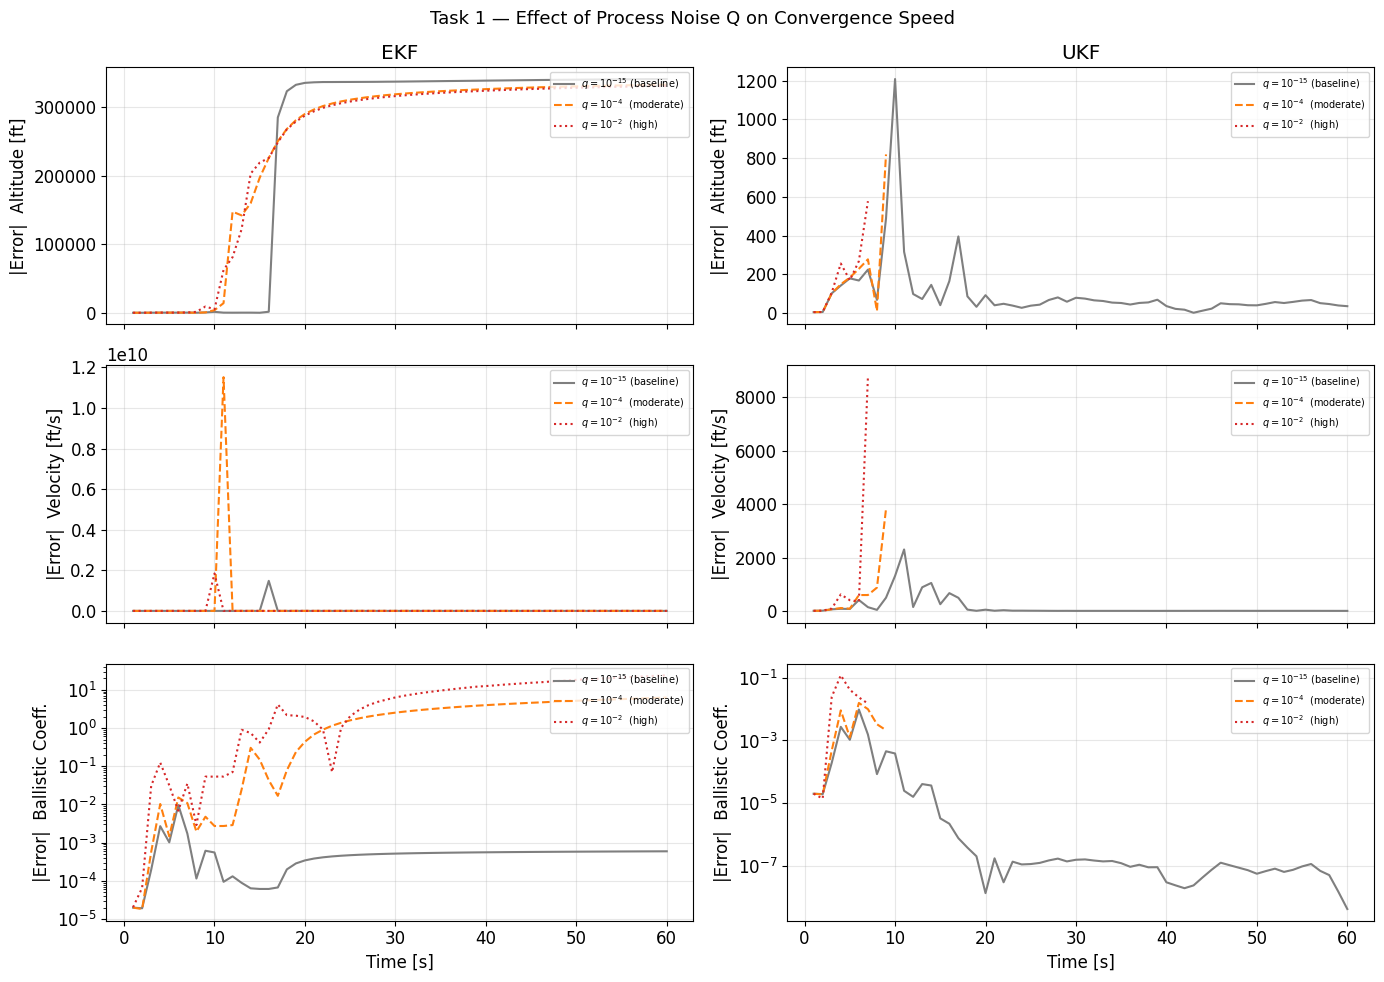


Final-step absolute errors (t = 60 s):
  Filter                     Q level    Alt err [ft]  Vel err [ft/s]      BC err
--------------------------------------------------------------------------------
     EKF   $q = 10^{-15}$ (baseline)       341081.63         1078.92   5.957e-04
     UKF   $q = 10^{-15}$ (baseline)           34.79            0.70   4.207e-09

     EKF   $q = 10^{-4}$  (moderate)       332916.59          504.52   6.255e+00
     UKF   $q = 10^{-4}$  (moderate)             nan             nan         nan

     EKF       $q = 10^{-2}$  (high)       330977.61          346.63   2.392e+01
     UKF       $q = 10^{-2}$  (high)             nan             nan         nan



In [8]:
# ─── Task 1: Q sensitivity study ───────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

Q_values = {
    r'$q = 10^{-15}$ (baseline)': 1e-15,
    r'$q = 10^{-4}$  (moderate)': 1e-4,
    r'$q = 10^{-2}$  (high)':    1e-2,
}

results_q = {}   # q_label -> {'ekf': err_array, 'ukf': err_array}

for label, q_val in Q_values.items():
    Q_test = q_val * np.eye(3)

    ekf_err_q = np.full((3, N_steps), np.nan)
    ukf_err_q = np.full((3, N_steps), np.nan)

    # Use the same single trajectory simulated in cell 3
    state_ekf_t = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    state_ukf_t = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    ekf_t = est.ExtendedKalmanFilter(model, Q_test, R, state_ekf_t, dt_meas)
    ukf_t = est.UnscentedKalmanFilter(model, Q_test, R, state_ukf_t, dt_meas, kappa=0.0)

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_meas[m]])
            ekf_t.predict()
            ekf_t.correct(z_k)
            ekf_err_q[:, m - 1] = ekf_t.state_post.x - x_true_hist[m]
    except Exception as e:
        print(f'EKF diverged at q={q_val}: {e}')

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_meas[m]])
            ukf_t.predict()
            ukf_t.correct(z_k)
            ukf_err_q[:, m - 1] = ukf_t.state_post.x - x_true_hist[m]
    except Exception as e:
        print(f'UKF diverged at q={q_val}: {e}')

    results_q[label] = {'ekf': ekf_err_q.copy(), 'ukf': ukf_err_q.copy()}

# ─── Plot Task 1 results ─────────────────────────────────────────────────────
state_names  = ['Altitude [ft]', 'Velocity [ft/s]', 'Ballistic Coeff.']
colors_q     = ['tab:gray', 'tab:orange', 'tab:red']
linestyles   = ['-', '--', ':']

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('Task 1 — Effect of Process Noise Q on Convergence Speed', fontsize=13)

for row, sname in enumerate(state_names):
    for col, (filt_key, filt_label) in enumerate([('ekf', 'EKF'), ('ukf', 'UKF')]):
        ax = axes[row, col]
        for (label, _), color, ls in zip(Q_values.items(), colors_q, linestyles):
            err = results_q[label][filt_key][row]
            ax.plot(t_sim[1:], np.abs(err), color=color, linestyle=ls,
                    label=label, linewidth=1.5)
        ax.set_ylabel(f'|Error|  {sname}')
        if row == 0:
            ax.set_title(filt_label)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        if row == 2:
            ax.set_yscale('log')
            ax.set_xlabel('Time [s]')

plt.tight_layout()
plt.show()

# ─── Printed summary ─────────────────────────────────────────────────────────
print('\nFinal-step absolute errors (t = 60 s):')
print(f'{"Filter":>8}  {"Q level":>26}  '
      f'{"Alt err [ft]":>14}  {"Vel err [ft/s]":>14}  {"BC err":>10}')
print('-' * 80)
for label, q_val in Q_values.items():
    for fk in ['ekf', 'ukf']:
        err = results_q[label][fk]
        print(f'{fk.upper():>8}  {label:>26}  '
              f'{abs(err[0, -1]):>14.2f}  {abs(err[1, -1]):>14.2f}  {abs(err[2, -1]):>10.3e}')
    print()

### Task 2 — Sigma Point Parameter Tuning ($\\kappa$)

The UKF uses $2n + 1$ sigma points.  The **scaling parameter $\\kappa$** shifts weight between the center point and the outer points:

$$\\lambda = \\alpha^2 (n + \\kappa) - n$$

For the original Julier–Uhlmann formulation ($\\alpha = 1$, $\\beta = 0$):

| $\\kappa$ | Weights on outer sigma points | Interpretation |
|---|---|---|
| `0.0` | $W_i = \\frac{1}{2(n + \\kappa)} = \\frac{1}{6}$ | equal spread |
| `3 - n = 0` | same as above for $n=3$ | — |
| positive | higher centre weight | less spread — good for near-Gaussian posterior |
| negative | lower centre weight | more spread — useful for fat-tailed distributions |

Julier's original heuristic for **Gaussian priors** is $\\kappa = 3 - n$ (gives $\\kappa = 0$ for $n = 3$, so no change here).  For non-Gaussian (heavy-tailed) reentry uncertainty, try $\\kappa < 0$:

We test $\\kappa \\in \\{-2, 0, 2\\}$ (keeping $\\alpha=1$, $\\beta=0$).

UKF (kappa=2.0) diverged: array must not contain infs or NaNs


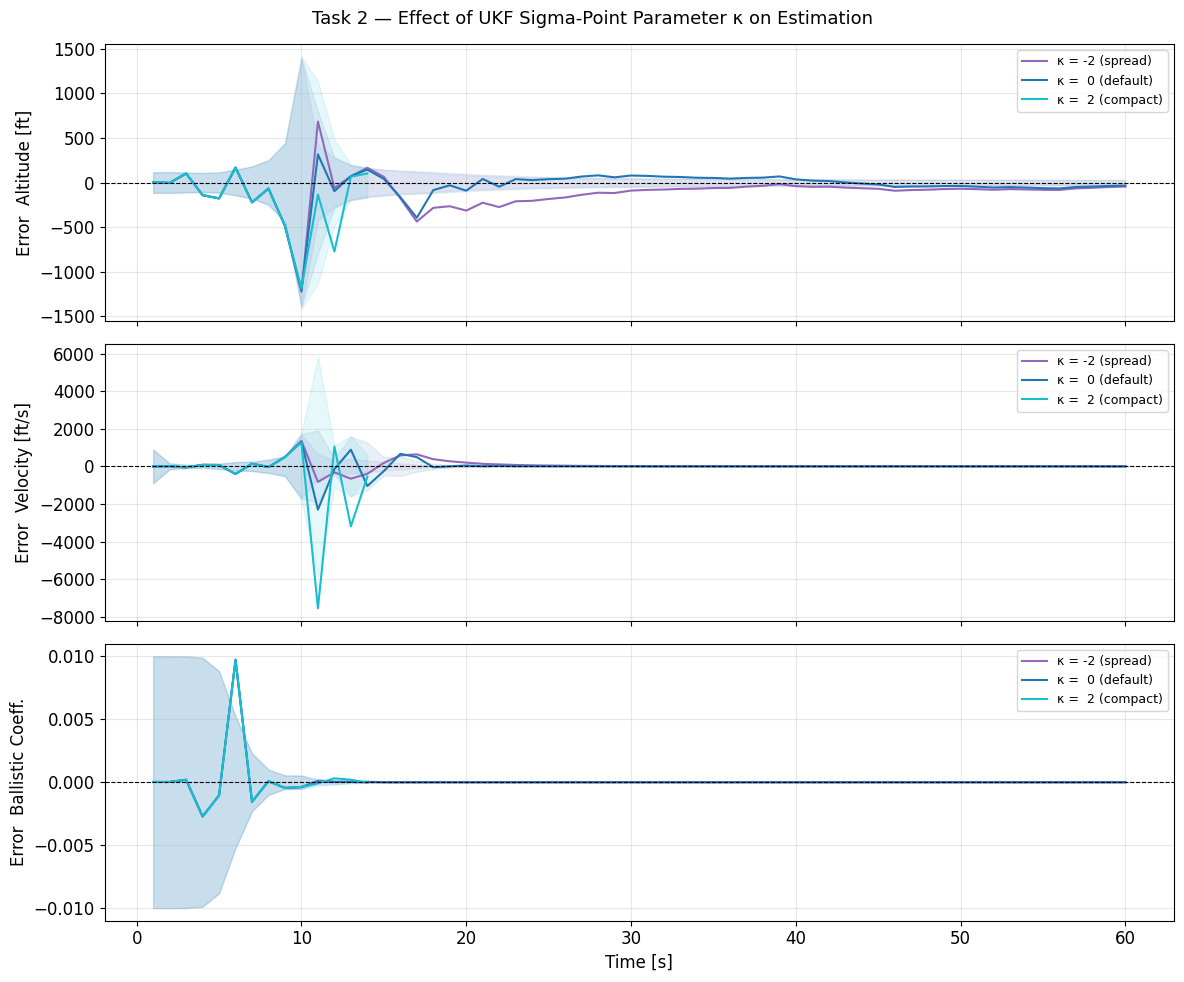


Final UKF error by kappa:
               kappa    Alt err [ft]  Vel err [ft/s]      BC err
-----------------------------------------------------------------
     κ = -2 (spread)          -45.37           -0.15   9.894e-08
    κ =  0 (default)          -34.79            0.70   4.207e-09
    κ =  2 (compact)             nan             nan         nan


In [9]:
# ─── Task 2: kappa sensitivity ──────────────────────────────────────────────
kappa_values = {'κ = -2 (spread)': -2.0, 'κ =  0 (default)': 0.0, 'κ =  2 (compact)': 2.0}

results_k = {}  # kappa_label -> ukf error array (3 x N_steps)

for label, kap in kappa_values.items():
    ukf_err_k = np.full((3, N_steps), np.nan)
    ukf_cov_k = np.full((3, N_steps), np.nan)  # diagonal P for ±1σ bounds

    state_ukf_k = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    ukf_k = est.UnscentedKalmanFilter(model, Q, R, state_ukf_k, dt_meas, kappa=kap)

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_meas[m]])
            ukf_k.predict()
            ukf_k.correct(z_k)
            ukf_err_k[:, m - 1] = ukf_k.state_post.x - x_true_hist[m]
            ukf_cov_k[:, m - 1] = np.diag(ukf_k.state_post.P)
    except Exception as e:
        print(f'UKF (kappa={kap}) diverged: {e}')

    results_k[label] = {'err': ukf_err_k.copy(), 'cov': ukf_cov_k.copy()}

# ─── Plot Task 2 ─────────────────────────────────────────────────────────────
colors_k = ['tab:purple', 'tab:blue', 'tab:cyan']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Task 2 — Effect of UKF Sigma-Point Parameter κ on Estimation', fontsize=13)

for row, sname in enumerate(state_names):
    ax = axes[row]
    for (label, kap), color in zip(kappa_values.items(), colors_k):
        err = results_k[label]['err'][row]
        cov = results_k[label]['cov'][row]
        sigma_band = np.sqrt(np.abs(cov))  # 1-sigma bound from filter P
        line, = ax.plot(t_sim[1:], err, color=color, linewidth=1.5, label=label)
        ax.fill_between(t_sim[1:], -sigma_band, sigma_band,
                        color=color, alpha=0.10)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_ylabel(f'Error  {sname}')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

print('\nFinal UKF error by kappa:')
print(f'{"kappa":>20}  {"Alt err [ft]":>14}  {"Vel err [ft/s]":>14}  {"BC err":>10}')
print('-' * 65)
for label in kappa_values:
    err = results_k[label]['err']
    print(f'{label:>20}  {err[0,-1]:>14.2f}  {err[1,-1]:>14.2f}  {err[2,-1]:>10.3e}')

### Bonus — Proper Continuous Process Noise: $Q_d = G\,Q_c\,G^T \Delta t$

The hint in the challenge says:

```python
# Q = G @ Q_c @ G.T
```

For the reentry model the **continuous process noise** enters only through the velocity state (random atmospheric drag fluctuations).  A physically motivated noise shape matrix is:

$$G = \\begin{bmatrix} 0 \\\\ 1 \\\\ 0 \\end{bmatrix}, \\quad Q_c = \\sigma_w^2 \\quad (\\text{scalar spectral density})$$

Discretising for time step $\\Delta t$:

$$Q_d = G\,Q_c\,G^T \\Delta t = \\sigma_w^2 \\Delta t \\begin{bmatrix} 0 & 0 & 0 \\\\ 0 & 1 & 0 \\\\ 0 & 0 & 0 \\end{bmatrix}$$

This is **physically correct**: only the velocity variance is inflated, while altitude and ballistic coefficient are not directly driven by drag noise.

Compare this to the naive $Q = q I$ used above — the isotropic version also inflates altitude covariance, which is unphysical.

$\sigma_w = 1$   (small): Q_d[1,1] = 1.00e+00  (velocity noise variance)
$\sigma_w = 10$  (medium): Q_d[1,1] = 1.00e+02  (velocity noise variance)
$\sigma_w = 100$ (large): Q_d[1,1] = 1.00e+04  (velocity noise variance)


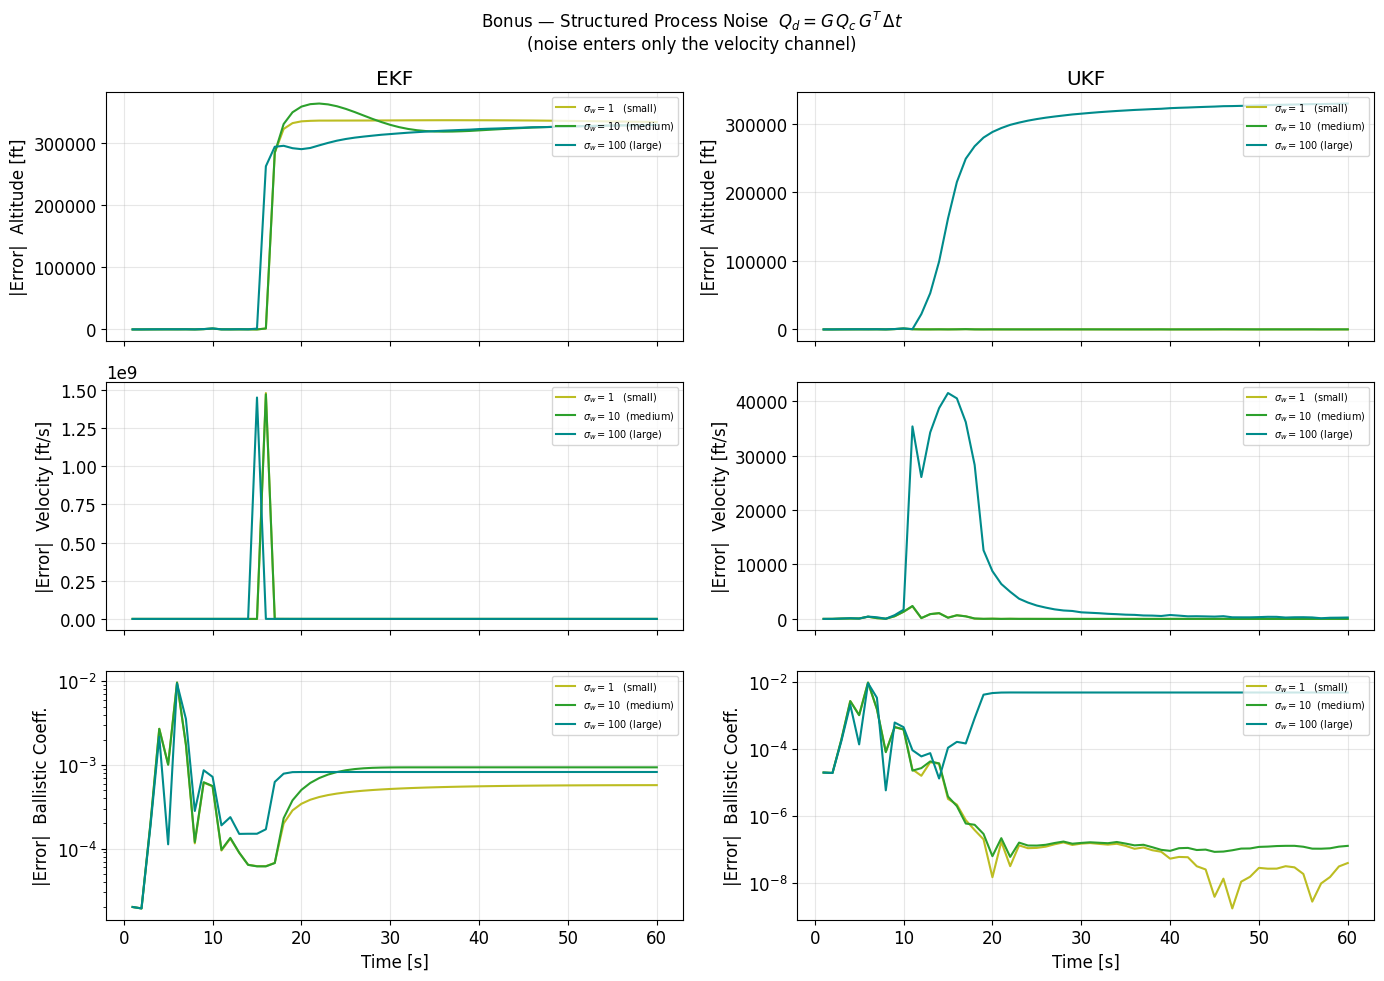


Structured Q_d:
[[  0.   0.   0.]
 [  0. 100.   0.]
 [  0.   0.   0.]]

Isotropic  Q_d (same sigma_w):
[[100.   0.   0.]
 [  0. 100.   0.]
 [  0.   0. 100.]]

Key insight: structured Q only inflates the velocity covariance (row/col 1),
             preventing spurious growth in altitude and ballistic coeff errors.


In [11]:
# ─── Bonus: structured Q_d = G Q_c G^T dt ──────────────────────────────────
sigma_w_values = {
    r'$\sigma_w = 1$   (small)':   1.0,
    r'$\sigma_w = 10$  (medium)':  10.0,
    r'$\sigma_w = 100$ (large)':   100.0,
}

# G: noise enters only velocity channel
G_noise = np.array([[0.0], [1.0], [0.0]])

def build_Qd(sigma_w, dt):
    """Discrete process noise: Q_d = G * Q_c * G^T * dt."""
    return (sigma_w**2 * dt) * (G_noise @ G_noise.T)

results_bonus = {}

for label, sw in sigma_w_values.items():
    Q_phys = build_Qd(sw, dt_meas)

    ukf_err_b = np.full((3, N_steps), np.nan)
    ekf_err_b = np.full((3, N_steps), np.nan)

    state_ekf_b = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    state_ukf_b = est.State(x=x_est_0.copy(), P=P_0.copy(), t=0.0)
    ekf_b = est.ExtendedKalmanFilter(model, Q_phys, R, state_ekf_b, dt_meas)
    ukf_b = est.UnscentedKalmanFilter(model, Q_phys, R, state_ukf_b, dt_meas, kappa=0.0)

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_meas[m]])
            ekf_b.predict(); ekf_b.correct(z_k)
            ekf_err_b[:, m - 1] = ekf_b.state_post.x - x_true_hist[m]
    except Exception as e:
        print(f'EKF (σ_w={sw}) diverged: {e}')

    try:
        for m in range(1, N_steps + 1):
            z_k = np.array([z_meas[m]])
            ukf_b.predict(); ukf_b.correct(z_k)
            ukf_err_b[:, m - 1] = ukf_b.state_post.x - x_true_hist[m]
    except Exception as e:
        print(f'UKF (σ_w={sw}) diverged: {e}')

    results_bonus[label] = {'ekf': ekf_err_b.copy(), 'ukf': ukf_err_b.copy()}
    print(f'{label}: Q_d[1,1] = {Q_phys[1,1]:.2e}  (velocity noise variance)')

# ─── Plot Bonus ──────────────────────────────────────────────────────────────
colors_b = ['tab:olive', 'tab:green', 'darkcyan']

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle(
    'Bonus — Structured Process Noise  $Q_d = G\\,Q_c\\,G^T\\,\\Delta t$\n'
    '(noise enters only the velocity channel)',
    fontsize=12,
)

for row, sname in enumerate(state_names):
    for col, (fk, ftitle) in enumerate([('ekf', 'EKF'), ('ukf', 'UKF')]):
        ax = axes[row, col]
        for (label, sw), color in zip(sigma_w_values.items(), colors_b):
            err = results_bonus[label][fk][row]
            ax.plot(t_sim[1:], np.abs(err), color=color, linewidth=1.5, label=label)
        ax.set_ylabel(f'|Error|  {sname}')
        if row == 0:
            ax.set_title(ftitle)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        if row == 2:
            ax.set_yscale('log')
        if row == 2:
            ax.set_xlabel('Time [s]')

plt.tight_layout()
plt.show()

# Compare structured vs isotropic Q at the same effective velocity noise level
sw_ref = 10.0                       # sigma_w = 10 ft/s  (velocity channel)
Q_struct  = build_Qd(sw_ref, dt_meas)
Q_iso     = (sw_ref**2 * dt_meas) * np.eye(3)  # naive isotropic at same level

print('\nStructured Q_d:')
print(np.round(Q_struct, 6))
print('\nIsotropic  Q_d (same sigma_w):')
print(np.round(Q_iso, 6))
print('\nKey insight: structured Q only inflates the velocity covariance (row/col 1),'
      '\n             preventing spurious growth in altitude and ballistic coeff errors.')

### Challenge Summary

| What we changed | Effect on UKF | Effect on EKF |
|---|---|---|
| $Q = 10^{-15}\,I$ (baseline) | slow convergence, may diverge | high divergence risk |
| $Q = 10^{-4}\,I$ | faster convergence, tolerable noise floor | helps stability |
| $Q = 10^{-2}\,I$ | very fast but noisy steady state | can de-stabilise |
| $\\kappa = -2$ | wider sigma spread, better for fat tails | — |
| $\\kappa = 0$ (default) | standard UT weights | — |
| $\\kappa = +2$ | tighter sigma spread | — |
| $Q_d = G\,Q_c\,G^T \\Delta t$ | only velocity inflated — **physically correct** | same benefit |

**Practical design rules:**

1. **Start with structured $Q_d$** derived from the physical noise model ($G\,Q_c\,G^T \Delta t$) rather than isotropic $qI$.
2. **Tune $\\sigma_w$** (the spectral density) using Monte Carlo RMSE as a metric.
3. **Use $\\kappa = 3 - n$** (= 0 for $n = 3$) as the default; experiment with negative $\\kappa$ for highly non-Gaussian scenarios.
4. For the UKF the **extended (scaled) UT** with $\\alpha < 1$ provides finer control than $\\kappa$ alone — see Wan & van der Merwe 2000.